In [ ]:
https://chatgpt.com/c/68a63f17-8948-8325-9f5e-01d9b3ebac8f
https://chatgpt.com/c/68ae260b-f820-832d-8afc-bf8f54ad22d4

In [ ]:
https://chatgpt.com/c/68b227d9-735c-8327-92d0-19ce3cbddc53

In [ ]:
import networkx as nx
import time
import random
import zipfile
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Set, Iterable
import heapq
from collections import defaultdict

In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from bisect import bisect_left
from typing import List, Tuple, Dict, Optional
import heapq
import math

# ---------------------------------------------------------------------------
# BlockList data structure (faithful Python rendition of Rust block_data_structure.rs)
# ---------------------------------------------------------------------------

NodeId = int
Cost = float


@dataclass
class PullResult:
    nodes: List[NodeId]
    min_upper_bound: Cost


class Block:
    __slots__ = ("capacity", "items", "upper_bound")

    def __init__(self, capacity: int, items: Optional[List[Tuple[NodeId, Cost]]] = None):
        self.capacity = int(capacity)
        self.items: List[Tuple[NodeId, Cost]] = sorted(items or [], key=lambda x: x[1])
        self.upper_bound: Cost = (self.items[-1][1] if self.items else float("-inf"))

    def __len__(self) -> int:
        return len(self.items)

    def _recompute_upper_bound(self) -> None:
        self.upper_bound = (self.items[-1][1] if self.items else float("-inf"))

    def add(self, node_id: NodeId, cost: Cost) -> Tuple[Optional["Block"], Optional["Block"]]:
        idx = bisect_left([c for _, c in self.items], cost)
        self.items.insert(idx, (node_id, cost))
        if len(self.items) <= self.capacity:
            self._recompute_upper_bound()
            return (self, None)
        mid = len(self.items) // 2
        left = Block(self.capacity, self.items[:mid])
        right = Block(self.capacity, self.items[mid:])
        return (left, right)

    def extend_front(self, pairs: List[Tuple[NodeId, Cost]]) -> List["Block"]:
        if not pairs:
            return [self]
        all_items = pairs + self.items
        all_items.sort(key=lambda x: x[1])
        blocks: List[Block] = []
        for i in range(0, len(all_items), self.capacity):
            blocks.append(Block(self.capacity, all_items[i:i + self.capacity]))
        return blocks

    def pop_min_many(self, k: int) -> List[Tuple[NodeId, Cost]]:
        if not self.items or k <= 0:
            return []
        take = min(k, len(self.items))
        out = self.items[:take]
        self.items = self.items[take:]
        self._recompute_upper_bound()
        return out


class BlockList:
    def __init__(self, M: int, initial_upper_bound: Cost = float("inf")) -> None:
        if M <= 0:
            raise ValueError("Block capacity M must be positive")
        self.M = int(M)
        self.blocks: List[Block] = []
        self.global_upper_bound: Cost = initial_upper_bound

    def _block_upper_bounds(self) -> List[Cost]:
        return [b.upper_bound for b in self.blocks]

    def _find_block_index_for_cost(self, cost: Cost) -> int:
        ubs = self._block_upper_bounds()
        return bisect_left(ubs, cost)

    def insert(self, node_id: NodeId, cost: Cost) -> None:
        idx = self._find_block_index_for_cost(cost)
        if idx == len(self.blocks):
            if self.blocks and len(self.blocks[-1]) < self.M and cost >= self.blocks[-1].items[-1][1]:
                blk = self.blocks[-1]
                left, right = blk.add(node_id, cost)
                if right is not None:
                    self.blocks.pop()
                    self.blocks.append(left)
                    self.blocks.append(right)
            else:
                self.blocks.append(Block(self.M, [(node_id, cost)]))
            return
        blk = self.blocks[idx]
        left, right = blk.add(node_id, cost)
        if right is None:
            self.blocks[idx] = left
        else:
            self.blocks[idx] = left
            self.blocks.insert(idx + 1, right)

    def batch_prepend(self, items: List[Tuple[NodeId, Cost]]) -> None:
        if not items:
            return
        items = sorted(items, key=lambda x: x[1])
        if not self.blocks:
            for i in range(0, len(items), self.M):
                self.blocks.append(Block(self.M, items[i:i + self.M]))
            return
        first = self.blocks.pop(0)
        new_blocks = first.extend_front(items)
        self.blocks = new_blocks + self.blocks

    def pull(self, limit: int) -> PullResult:
        if limit <= 0 or not self.blocks:
            return PullResult(nodes=[], min_upper_bound=(self.blocks[0].upper_bound if self.blocks else float("inf")))
        taken_nodes: List[NodeId] = []
        remaining = limit
        i = 0
        while i < len(self.blocks) and remaining > 0:
            blk = self.blocks[i]
            popped = blk.pop_min_many(remaining)
            if popped:
                taken_nodes.extend(n for n, _ in popped)
                remaining -= len(popped)
            if len(blk) == 0:
                self.blocks.pop(i)
            else:
                i += 1
        min_ub = self.blocks[0].upper_bound if self.blocks else float("inf")
        return PullResult(nodes=taken_nodes, min_upper_bound=min_ub)

    def __len__(self) -> int:
        return sum(len(b) for b in self.blocks)

    def is_empty(self) -> bool:
        return not self.blocks

    def peek_min_upper_bound(self) -> Cost:
        return self.blocks[0].upper_bound if self.blocks else float("inf")

    def debug_dump(self) -> List[List[Tuple[NodeId, Cost]]]:
        return [b.items[:] for b in self.blocks]


# ---------------------------------------------------------------------------
# BMSSSP implementation (distance-only) using BlockList
# ---------------------------------------------------------------------------

@dataclass(order=True)
class State:
    cost: Cost
    node: NodeId


def bmssp_distance_only(graph: Dict[NodeId, List[Tuple[NodeId, Cost]]],
                        source: NodeId,
                        block_capacity: int = 32,
                        batch_size: int = 16) -> Dict[NodeId, Cost]:
    dist: Dict[NodeId, Cost] = {source: 0.0}
    visited: set[NodeId] = set()
    frontier = BlockList(block_capacity)
    frontier.insert(source, 0.0)

    while not frontier.is_empty():
        pulled = frontier.pull(batch_size)
        layer_nodes = pulled.nodes
        for u in layer_nodes:
            if u in visited:
                continue
            visited.add(u)
            du = dist[u]
            for v, w in graph.get(u, []):
                nd = du + w
                if v not in dist or nd < dist[v]:
                    dist[v] = nd
                    frontier.insert(v, nd)
    return dist


# ---------------------------------------------------------------------------
# Baseline Dijkstra
# ---------------------------------------------------------------------------

def dijkstra_distance_only(graph: Dict[NodeId, List[Tuple[NodeId, Cost]]],
                           source: NodeId) -> Dict[NodeId, Cost]:
    dist: Dict[NodeId, Cost] = {source: 0.0}
    pq: List[Tuple[Cost, NodeId]] = [(0.0, source)]
    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        for v, w in graph.get(u, []):
            nd = d + w
            if v not in dist or nd < dist[v]:
                dist[v] = nd
                heapq.heappush(pq, (nd, v))
    return dist


In [ ]:
def make_random_graph(n: int, m: int, weight_range=(1, 10)) -> Dict[int, List[Tuple[int, float]]]:
    graph: Dict[int, List[Tuple[int, float]]] = {i: [] for i in range(n)}
    for _ in range(m):
        u = random.randrange(n)
        v = random.randrange(n)
        if u == v:
            continue
        w = random.randint(*weight_range)
        graph[u].append((v, float(w)))
    return graph

def test_bmssp_vs_dijkstra(n=20, m=60, trials=5):
    for t in range(trials):
        g = make_random_graph(n, m)
        print(g)
        src = random.randrange(n)
        d1 = dijkstra_distance_only(g, src)
        d2 = bmssp_distance_only(g, src, block_capacity=8, batch_size=4)
        ok = True
        all_nodes = set(d1.keys()) | set(d2.keys())
        for node in all_nodes:
            v1 = d1.get(node, float("inf"))
            v2 = d2.get(node, float("inf"))
            if abs(v1 - v2) > 1e-9:
                ok = False
                print(f"  mismatch at node {node}: dijkstra={v1}, bmssp={v2}")
        print(f"Trial {t}: src={src}, match={ok}")
test_bmssp_vs_dijkstra()

{0: [(7, 2.0), (10, 10.0), (17, 9.0)], 1: [(8, 2.0), (17, 10.0)], 2: [(18, 8.0), (13, 5.0), (14, 3.0), (17, 10.0)], 3: [(17, 5.0), (17, 3.0), (0, 1.0), (17, 4.0), (2, 2.0)], 4: [(8, 1.0)], 5: [(18, 7.0)], 6: [(1, 6.0), (5, 2.0)], 7: [(11, 8.0), (6, 8.0), (6, 9.0)], 8: [(7, 4.0), (14, 7.0), (0, 6.0)], 9: [(1, 5.0)], 10: [(3, 9.0), (13, 5.0), (11, 4.0), (2, 6.0)], 11: [(5, 4.0), (15, 7.0), (13, 8.0)], 12: [(17, 9.0), (15, 10.0), (7, 3.0)], 13: [(7, 8.0)], 14: [(7, 3.0), (17, 9.0), (0, 8.0), (8, 8.0), (11, 2.0), (8, 6.0)], 15: [(6, 8.0), (5, 6.0), (1, 3.0), (16, 3.0)], 16: [(9, 4.0), (10, 8.0)], 17: [(7, 7.0)], 18: [], 19: [(14, 1.0), (0, 9.0), (8, 7.0), (18, 7.0), (1, 8.0)]}
Trial 0: src=6, match=True
{0: [(14, 1.0), (3, 4.0)], 1: [(11, 4.0), (10, 8.0)], 2: [(14, 5.0), (9, 3.0), (13, 5.0)], 3: [(2, 5.0), (14, 1.0)], 4: [(2, 5.0), (11, 8.0), (17, 5.0), (2, 1.0), (9, 8.0)], 5: [(4, 1.0), (11, 5.0), (13, 6.0), (1, 1.0)], 6: [(11, 2.0), (9, 4.0)], 7: [(17, 8.0), (3, 10.0), (12, 1.0)], 8: [(1

In [ ]:
neighbors = {
0: [(1, 0.0), (2, 1.0), (7, 5.0)],
1: [(3, 3.0), (4, 2.0)],
2: [(4, 3.0), (5, 2.0)],
3: [(6, 2.0)],
4: [(6, 2.0)],
5: [],
6: [(8, 3.0)],
7: [(9, 2.0)],
8: [(10, 1.0)],
9: [(10, 2.0)],
10: [],
}
t0 = time.time()
dist_bmssp = bmssp_distance_only(neighbors, 0)
t1 = time.time()
print("time", t1 - t0, "\ndist", dist_bmssp)

t2 = time.time()
dist_dijkstra = dijkstra_distance_only(neighbors, 0)
t3 = time.time()
print("time", t3 - t2, "\ndist", dist_dijkstra)

print(dist_bmssp == dist_dijkstra)

time 0.00030159950256347656 
dist {0: 0.0, 1: 0.0, 2: 1.0, 7: 5.0, 3: 3.0, 4: 2.0, 5: 3.0, 9: 7.0, 6: 4.0, 10: 8.0, 8: 7.0}
time 0.00015234947204589844 
dist {0: 0.0, 1: 0.0, 2: 1.0, 7: 5.0, 3: 3.0, 4: 2.0, 5: 3.0, 6: 4.0, 8: 7.0, 9: 7.0, 10: 8.0}
True


In [ ]:
import networkx as nx
import numpy as np
from scipy.stats import entropy

def degree_distribution_entropy(G, base=2, normalized=True):
    degrees = [d for _, d in G.degree()]
    values, counts = np.unique(degrees, return_counts=True)
    pk = counts / counts.sum()
    H = entropy(pk, base=base)
    if normalized:
        K = len(values)
        if K > 1:
            H = H  / np.log(K) * np.log(base)
    return H

def generate_ba_with_entropy(n, target_entropy, tol=0.05, max_iter=50, seed=None):
    """
    Generate a Barabási–Albert graph with size n that has
    normalized entropy close to target_entropy.

    Parameters:
        n (int): Number of nodes
        target_entropy (float): Desired normalized entropy in [0,1]
        tol (float): Acceptable deviation from target_entropy
        max_iter (int): Maximum number of trials
        seed (int): Random seed

    Returns:
        G (networkx.Graph), entropy_value (float)
    """
    rng = np.random.default_rng(seed)

    best_G, best_entropy = None, None
    best_diff = float("inf")

    # The BA parameter m (edges per new node) controls heterogeneity
    for _ in range(max_iter):
        m = rng.integers(1, max(2, n//2))  # pick m between 1 and n/2
        G = nx.barabasi_albert_graph(n, m, seed=seed)
        H = degree_distribution_entropy(G, normalized=True)

        if target_entropy is None:
          best_G, best_entropy = G, H
          break

        diff = abs(H - target_entropy)
        if diff < best_diff:
            best_G, best_entropy, best_diff = G, H, diff
            if diff <= tol:
                break

    return best_G, best_entropy

In [ ]:
G, H = generate_ba_with_entropy(n=100, target_entropy=1, tol=0.05, seed=13)
print("Achieved normalized entropy:", H)
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges(), "Degree:", np.mean([d for _, d in G.degree()]))

Achieved normalized entropy: 0.9642634185429758
Nodes: 100 Edges: 2464 Degree: 49.28


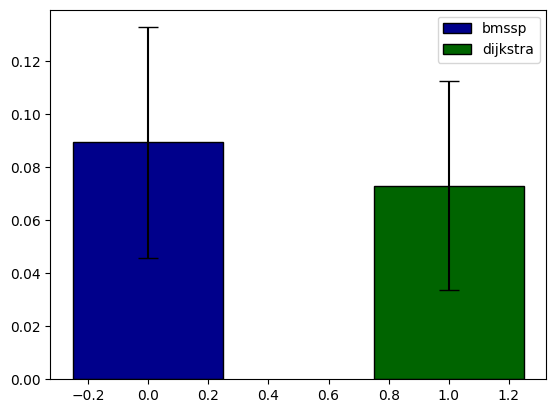

In [ ]:
def run_once(n=1000, target_entropy=None, seed=None):
    g, h = generate_ba_with_entropy(n=n, target_entropy=target_entropy, tol=0.05, seed=seed)

    for u, v in g.edges:
        g.edges[u, v]['weight'] = random.uniform(1.0, 10.0)

    neighbors = {}
    for i in g.nodes:
        edges = [(j, float(g.edges[i, j]['weight'])) for j in g.neighbors(i)]
        neighbors[i] = edges

    src = 0

    t0 = time.time()
    dist_bmssp = bmssp_distance_only(neighbors, src)
    t1 = time.time()

    t2 = time.time()
    dist_dijkstra = dijkstra_distance_only(neighbors, src)
    t3 = time.time()

    return t1-t0, t3-t2

times = [run_once() for i in range(3)]

t, y = np.asarray(times).mean(0), np.std(np.asarray(times), axis=0)
barWidth = 0.5
r1 = np.arange(len(t))
r2 = [x + barWidth for x in r1]

# Create blue bars
plt.bar(r1, t, width=barWidth, edgecolor='black',
        yerr=y, capsize=7, label=['bmssp', 'dijkstra'],
        color=['darkblue', 'darkgreen'])

plt.legend()

In [ ]:
g = nx.read_gml(zipfile.ZipFile('/content/drive/MyDrive/20230716.gml.geo.zip', 'r')\
                                        .open('20230716.gml.geo'))
components = [g.subgraph(c)
                for c in sorted(nx.connected_components(g),
                    key=len, reverse=True)]
g = components[0]
g = nx.convert_node_labels_to_integers(g)
g = nx.DiGraph(g)
random.seed(13)
to_remove = []
for u, v in g.edges:
    g.edges[u, v]['cltv_expiry_delta'] = float(g.edges[u, v]['cltv_expiry_delta'])
    if random.sample([True, False], 1)[0]:
      to_remove.append((u, v))

g.remove_edges_from(to_remove)
print(g)

neighbors = {}
for i in g.nodes:
    edges = [(j, float(g.edges[i, j]['cltv_expiry_delta'])) for j in g.neighbors(i)]
    neighbors[i] = edges

DiGraph with 15071 nodes and 64370 edges


In [ ]:
neighbors = {}
for i in g.nodes:
    edges = [(j, float(g.edges[i, j]['cltv_expiry_delta'])) for j in g.neighbors(i)]
    neighbors[i] = edges

In [ ]:
start = 0

t0 = time.time()
dist_bmssp = bmssp_distance_only(neighbors, start)
t1 = time.time()
print("dist_bmssp time", t1 - t0, "\ndist", np.asarray(dist_bmssp))

t2 = time.time()
dist_nx = nx.single_source_dijkstra_path_length(g, start, weight="cltv_expiry_delta")
t3 = time.time()
print("dist_nx time", t3 - t2, "\ndist", np.asarray(list(dict(sorted(dist_nx.items(), key=lambda x:x[0])).values())))

t4 = time.time()
dist_dijkstra = dijkstra_distance_only(neighbors, start)
t5 = time.time()
print("dist_dijkstra time", t5 - t4, "\ndist", np.asarray(dist_dijkstra))

dist_bmssp time 0.14495420455932617 
dist {0: 0.0, 708: 80.0, 29: 160.0, 51: 160.0, 72: 160.0, 99: 160.0, 100: 156.0, 126: 160.0, 129: 160.0, 157: 160.0, 179: 160.0, 184: 160.0, 261: 160.0, 265: 160.0, 271: 160.0, 298: 160.0, 302: 150.0, 313: 160.0, 343: 160.0, 363: 160.0, 373: 160.0, 401: 160.0, 431: 160.0, 433: 160.0, 458: 138.0, 530: 160.0, 537: 138.0, 545: 150.0, 549: 160.0, 556: 138.0, 566: 160.0, 571: 138.0, 576: 160.0, 578: 98.0, 582: 160.0, 587: 160.0, 615: 116.0, 626: 156.0, 638: 98.0, 657: 160.0, 658: 160.0, 659: 160.0, 662: 156.0, 666: 160.0, 668: 156.0, 672: 98.0, 680: 160.0, 688: 160.0, 700: 160.0, 704: 160.0, 1223: 120.0, 4975: 180.0, 11683: 224.0, 3501: 160.0, 734: 160.0, 4855: 120.0, 1161: 114.0, 11606: 114.0, 6766: 160.0, 4528: 160.0, 2457: 120.0, 1509: 160.0, 2068: 160.0, 11901: 156.0, 1165: 156.0, 1269: 160.0, 1684: 160.0, 2144: 120.0, 5134: 120.0, 2733: 148.0, 782: 116.0, 10064: 98.0, 2052: 120.0, 11168: 160.0, 9568: 120.0, 920: 160.0, 6970: 156.0, 7621: 120.0, 1255

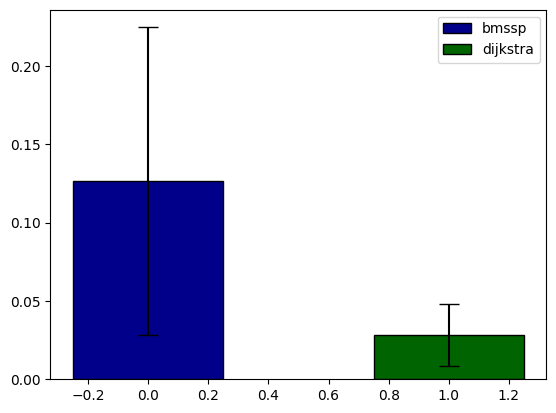

In [ ]:
def run_once():
    i = random.randint(0, len(neighbors))
    #t2 = time.time()
    #dist_nx = nx.single_source_dijkstra_path_length(g, i, weight="cltv_expiry_delta")
    #t3 = time.time()

    t4 = time.time()
    dist_dijkstra = dijkstra_distance_only(neighbors, i)
    t5 = time.time()

    t0 = time.time()
    dist_bmssp = bmssp_distance_only(neighbors, i)
    t1 = time.time()

    return t1-t0, t5-t4 # t3-t2,
times = [run_once() for i in range(100)]

t, y = np.asarray(times).mean(0), np.std(np.asarray(times), axis=0)
barWidth = 0.5
r1 = np.arange(len(t))
r2 = [x + barWidth for x in r1]

# Create blue bars
plt.bar(r1, t, width=barWidth, edgecolor='black',
        yerr=y, capsize=7, label=['bmssp', 'dijkstra'],
        color=['darkblue', 'darkgreen'])

plt.legend()